<a href="https://colab.research.google.com/github/willfinnigan/kinetics/blob/master/examples/Advanced_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install the required modules
%%capture
!pip install kinetics

In [1]:
# Import the required modules
import kinetics
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format ='retina'

In [ ]:
# Step 1: Define the enzymatic reactions
enzyme_1 = kinetics.Uni(
    kcat='enz1_kcat',
    kma='enz1_km',
    enz='enz_1',
    a='A',
    substrates=['A'],
    products=['B']
)

enzyme_2 = kinetics.Uni(
    kcat='enz2_kcat',
    kma='enz2_km',
    enz='enz_2',
    a='B',
    substrates=['B'],
    products=['C']
)

# Step 2: Define parameter distributions for uncertainty analysis
# Format: (min_value, max_value)
enzyme_1.parameter_distributions = {
    'enz1_kcat': (90, 110),      # kcat varies from 90-110 s⁻¹
    'enz1_km': (2000, 6000)      # Km varies from 2000-6000 µM
}

enzyme_2.parameter_distributions = {
    'enz2_kcat': (25, 35),       # kcat varies from 25-35 s⁻¹
    'enz2_km': (1, 10000)        # Km varies from 1-10000 µM (log scale)
}

# Step 3: Set up the model
model = kinetics.Model()
model.set_time(0, 1000, 100)  # 0-1000 seconds, 100 time points
model.add_reaction(enzyme_1)
model.add_reaction(enzyme_2)

# Step 4: Configure the sampler
# SalibSaltelliSampler uses Saltelli sampling for Sobol analysis
sampler = kinetics.SalibSaltelliSampler(
    num_samples=1000,              # Number of samples (more = better statistics)
    log_parameters=['enz2_km']     # Parameters to sample on log scale
)

# Step 5: Run the multi-parameter simulation
initial_conditions = {
    "A": 10000,    # 10 mM substrate A
    "enz_1": 5,    # 5 µM enzyme 1
    "enz_2": 2     # 2 µM enzyme 2
}

result = model.run_multi(initial_conditions, sampler)

100%|██████████| 6000/6000 [00:52<00:00, 113.86it/s]


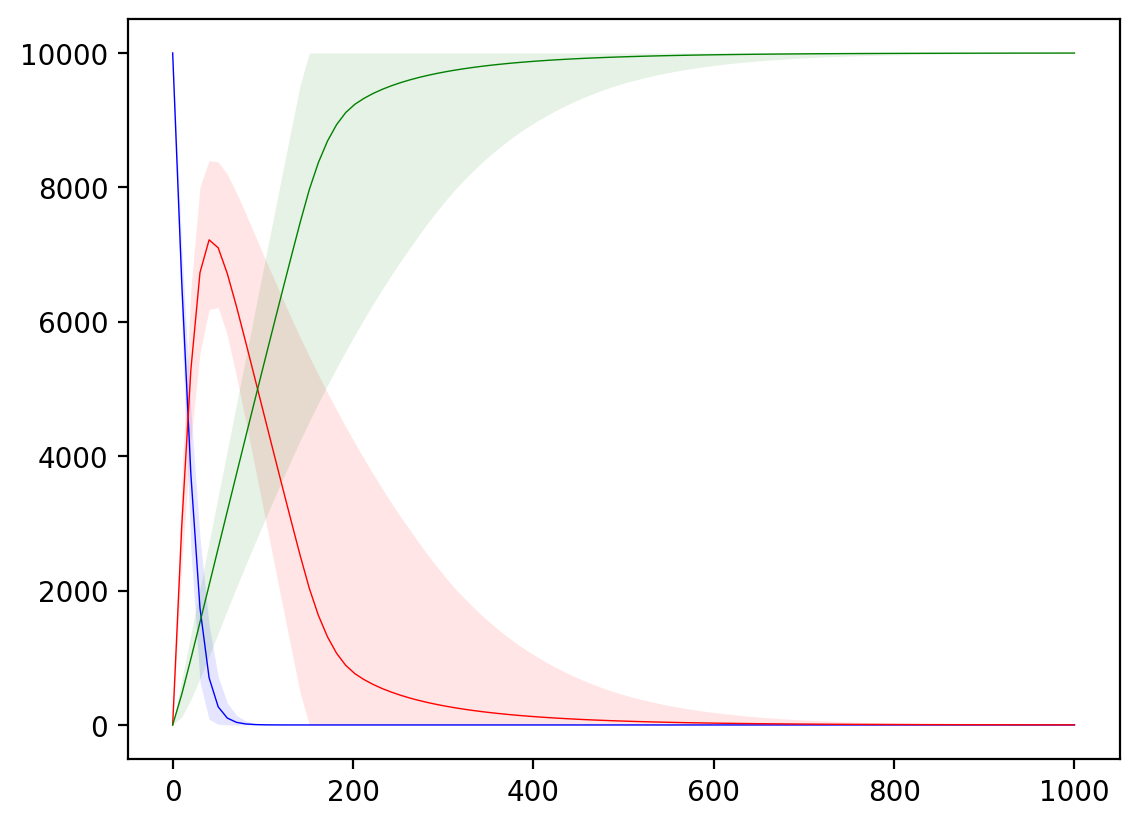

In [4]:
result.plot('A')
result.plot('B')
result.plot('C')
plt.show()

Sensitivity Analysis for [B] at t=200s:
                 S1   S1_conf        ST   ST_conf
enz1_kcat -0.000038  0.000539  0.000034  0.000006
enz1_km   -0.000071  0.000922  0.000136  0.000024
enz2_kcat  0.017103  0.017343  0.041190  0.006786
enz2_km    0.954835  0.107375  0.979004  0.064452


/Users/willfinnigan/miniforge3/envs/data/lib/python3.11/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


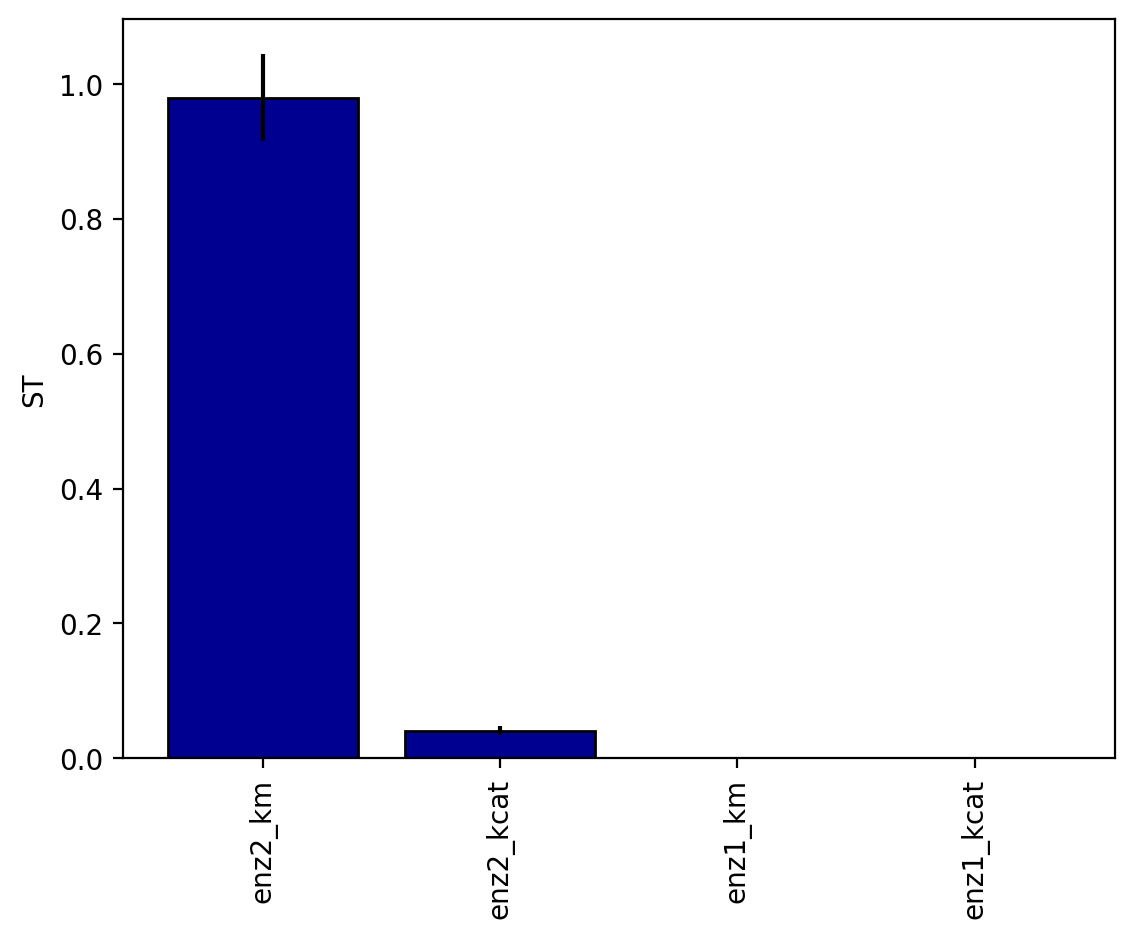

In [10]:
# Analyze sensitivity for [B] at t=200 seconds
sa_result = kinetics.analyze_sensitivity_at_timepoint(
    result=result,
    sampler=sampler,
    species='B',
    timepoint=200,
    threshold=0 # Threshold for sensitivity analysis (0 means all values are considered sensitive)
)

# Display results
print("Sensitivity Analysis for [B] at t=200s:")
print(sa_result.data)

# Visualize results
sa_result.plot()

Sensitivity Analysis for time to reach [A] = 50 µM:
                 S1   S1_conf        ST   ST_conf
enz1_kcat  0.081237  0.032020  0.129793  0.010073
enz1_km    0.866165  0.078412  0.929434  0.062554


/Users/willfinnigan/miniforge3/envs/data/lib/python3.11/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


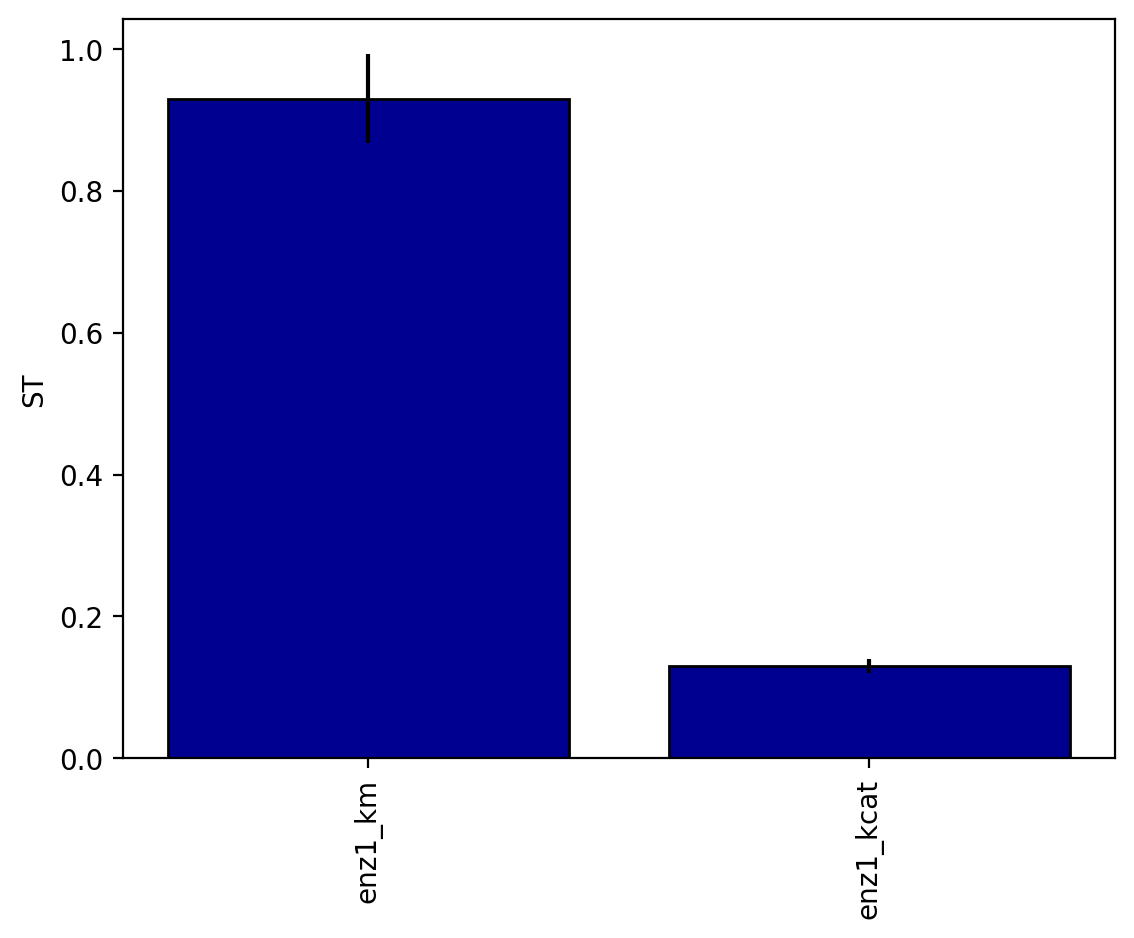

In [17]:
# Analyze sensitivity for time to reach [A] = 50 µM
sa_result = kinetics.analyze_sensitivity_time_to_concentration(
    result=result,
    sampler=sampler,
    species='A',
    concentration=50,
    mode='<=',       # Time to reach or be less than concentration
    threshold=0
)

print("Sensitivity Analysis for time to reach [A] = 50 µM:")
print(sa_result.data)

# Visualize results
sa_result.plot()